CA vs AA total: 201
CAA vs AA total: 88
CA vs CAA total: 29


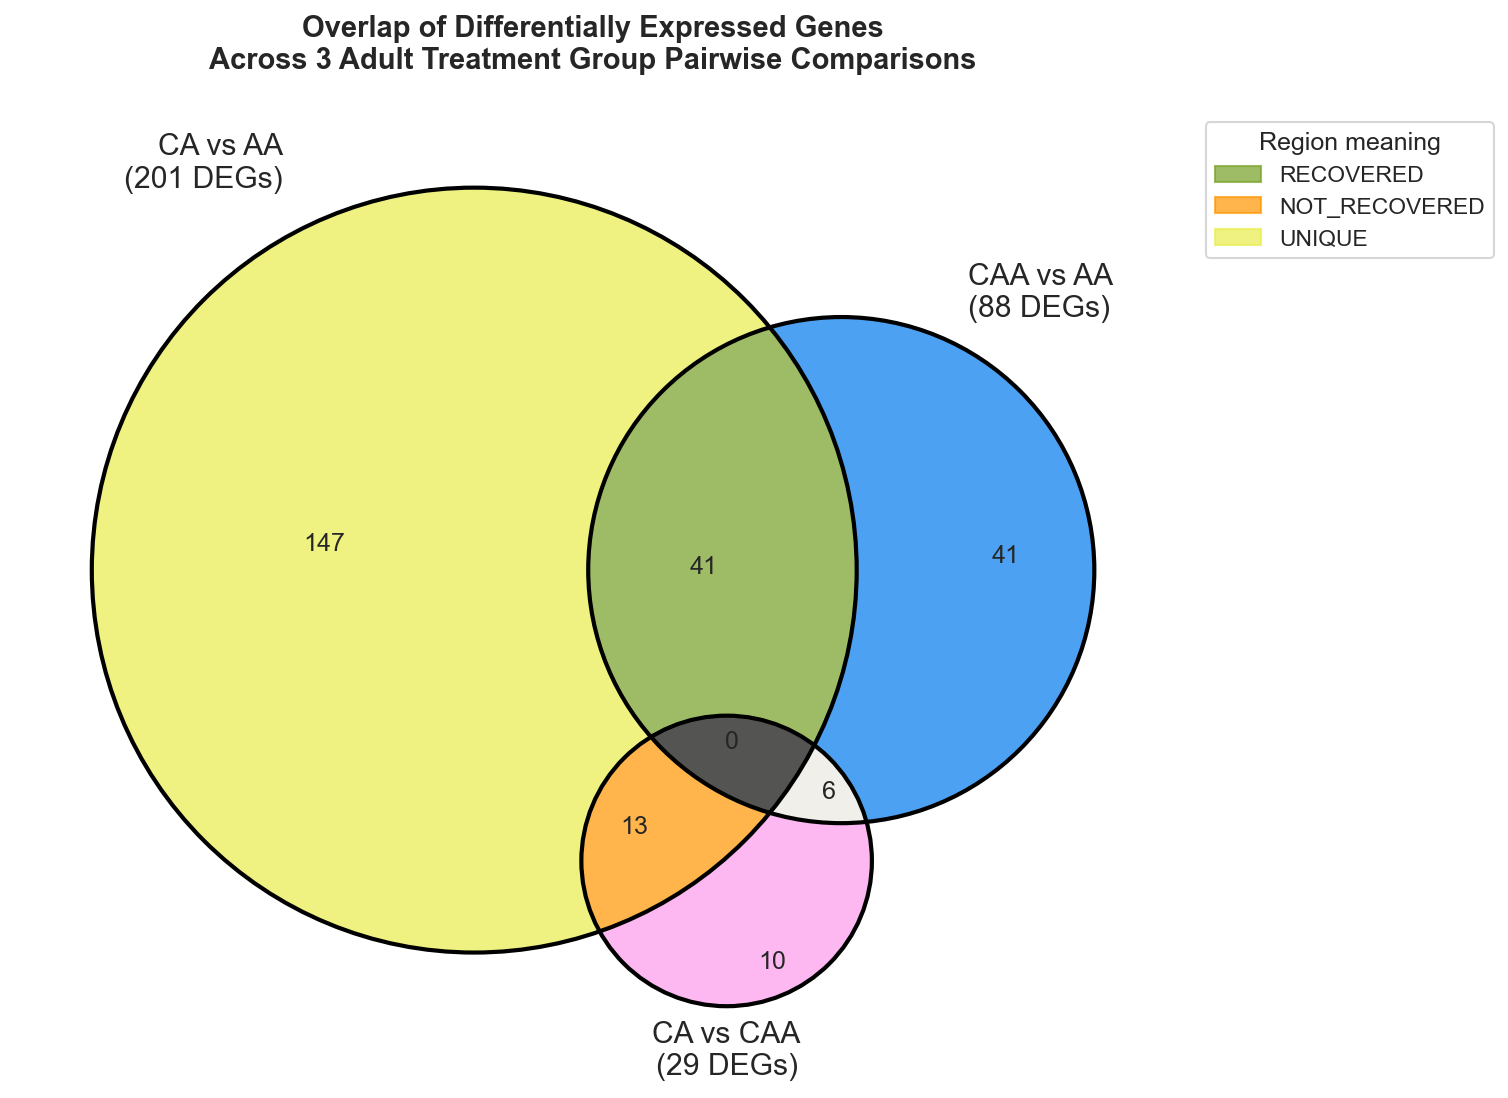

In [ ]:
"""
Venn Diagram of DEG Overlaps
============================
Creates Venn diagram showing the overlap of differentially 
expressed genes across the three adult groups of pairwise comparisons.

"RECOVERED = (CA vs AA) ∩ (CAA vs AA)"
"NOT_RECOVERED = (CA vs AA) - (CAA vs AA) - (CA vs CAA)"
"UNIQUE = (CA vs AA) ∩ (CA vs CAA) - (CAA vs AA)"
"""

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Liberation Sans', 'DejaVu Sans']
matplotlib.rcParams['svg.fonttype'] = 'none'
import seaborn as sns
sns.set_theme(style="ticks")
from matplotlib_venn import venn3, venn3_circles
import pandas as pd
import matplotlib.patches as mpatches

# =============================================================================
# LOAD DATA - Modify paths as needed
# =============================================================================
ca_vs_aa = pd.read_csv('A_inoA_vs_B2_conA_significant.csv')
caa_vs_aa = pd.read_csv('B1_reintro_vs_B2_conA_significant.csv')
ca_vs_caa = pd.read_csv('A_inoA_vs_B1_reintro_significant.csv')

# Extract gene sets
ca_vs_aa_genes = set(ca_vs_aa['gene_name'].tolist())
caa_vs_aa_genes = set(caa_vs_aa['gene_name'].tolist())
ca_vs_caa_genes = set(ca_vs_caa['gene_name'].tolist())

# =============================================================================
# CALCULATE OVERLAPS
# =============================================================================
ca_aa = ca_vs_aa_genes
caa_aa = caa_vs_aa_genes
ca_caa = ca_vs_caa_genes

# Venn regions
only_ca_aa = len(ca_aa - caa_aa - ca_caa)
only_caa_aa = len(caa_aa - ca_aa - ca_caa)
only_ca_caa = len(ca_caa - ca_aa - caa_aa)
ca_aa_and_caa_aa = len((ca_aa & caa_aa) - ca_caa)
ca_aa_and_ca_caa = len((ca_aa & ca_caa) - caa_aa)
caa_aa_and_ca_caa = len((caa_aa & ca_caa) - ca_aa)
all_three = len(ca_aa & caa_aa & ca_caa)

print(f"CA vs AA total: {len(ca_aa)}")
print(f"CAA vs AA total: {len(caa_aa)}")
print(f"CA vs CAA total: {len(ca_caa)}")

# =============================================================================
# CREATE FIGURE - Modify colors and labels as needed
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Create Venn diagram
v = venn3(subsets=(only_ca_aa, only_caa_aa, ca_aa_and_caa_aa, 
                   only_ca_caa, ca_aa_and_ca_caa, caa_aa_and_ca_caa, all_three),
          set_labels=(f'CA vs AA\n({len(ca_aa)} DEGs)', 
                      f'CAA vs AA\n({len(caa_aa)} DEGs)', 
                      f'CA vs CAA\n({len(ca_caa)} DEGs)'),
          ax=ax)

# Add circles
c = venn3_circles(subsets=(only_ca_aa, only_caa_aa, ca_aa_and_caa_aa, 
                           only_ca_caa, ca_aa_and_ca_caa, caa_aa_and_ca_caa, all_three),
                  linestyle='solid', linewidth=2, ax=ax)

# =============================================================================
# CUSTOMIZE COLORS - Modify these to match your preferences
# =============================================================================
colors = {
    '100': '#E9ED4C',  # Only CA vs AA - yellow
    '010': '#0279EE',  # Only CAA vs AA - blue
    '001': '#FD9BED',  # Only CA vs CAA - pink
    '110': '#75A025',  # CA vs AA & CAA vs AA - green (RECOVERED)
    '101': '#FF9400',  # CA vs AA & CA vs CAA - orange (UNIQUE-like)
    '011': '#ECE9E2',  # CAA vs AA & CA vs CAA - gray
    '111': "#0B0B09"   #random color
}

for idx in ['100', '010', '001', '110', '101', '011', '111']:
    if v.get_patch_by_id(idx):
        v.get_patch_by_id(idx).set_color(colors[idx])
        v.get_patch_by_id(idx).set_alpha(0.7)

# =============================================================================
# ADD TITLE AND SAVE
# =============================================================================
ax.set_title('Overlap of Differentially Expressed Genes\nAcross 3 Adult Treatment Group Pairwise Comparisons', 
             fontsize=14, fontweight='bold', pad=20)

legend_patches = [
    mpatches.Patch(color='#75A025', alpha=0.7, label='RECOVERED'),
    mpatches.Patch(color='#FF9400', alpha=0.7, label='NOT_RECOVERED'),
    mpatches.Patch(color='#E9ED4C', alpha=0.7, label='UNIQUE'),
]

ax.legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(1.02, 1), 
          title='Region meaning', frameon=True)

plt.tight_layout()
# plt.savefig('Venn_DEG_Overlap.png', dpi=300, bbox_inches='tight')

plt.show()




findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberati

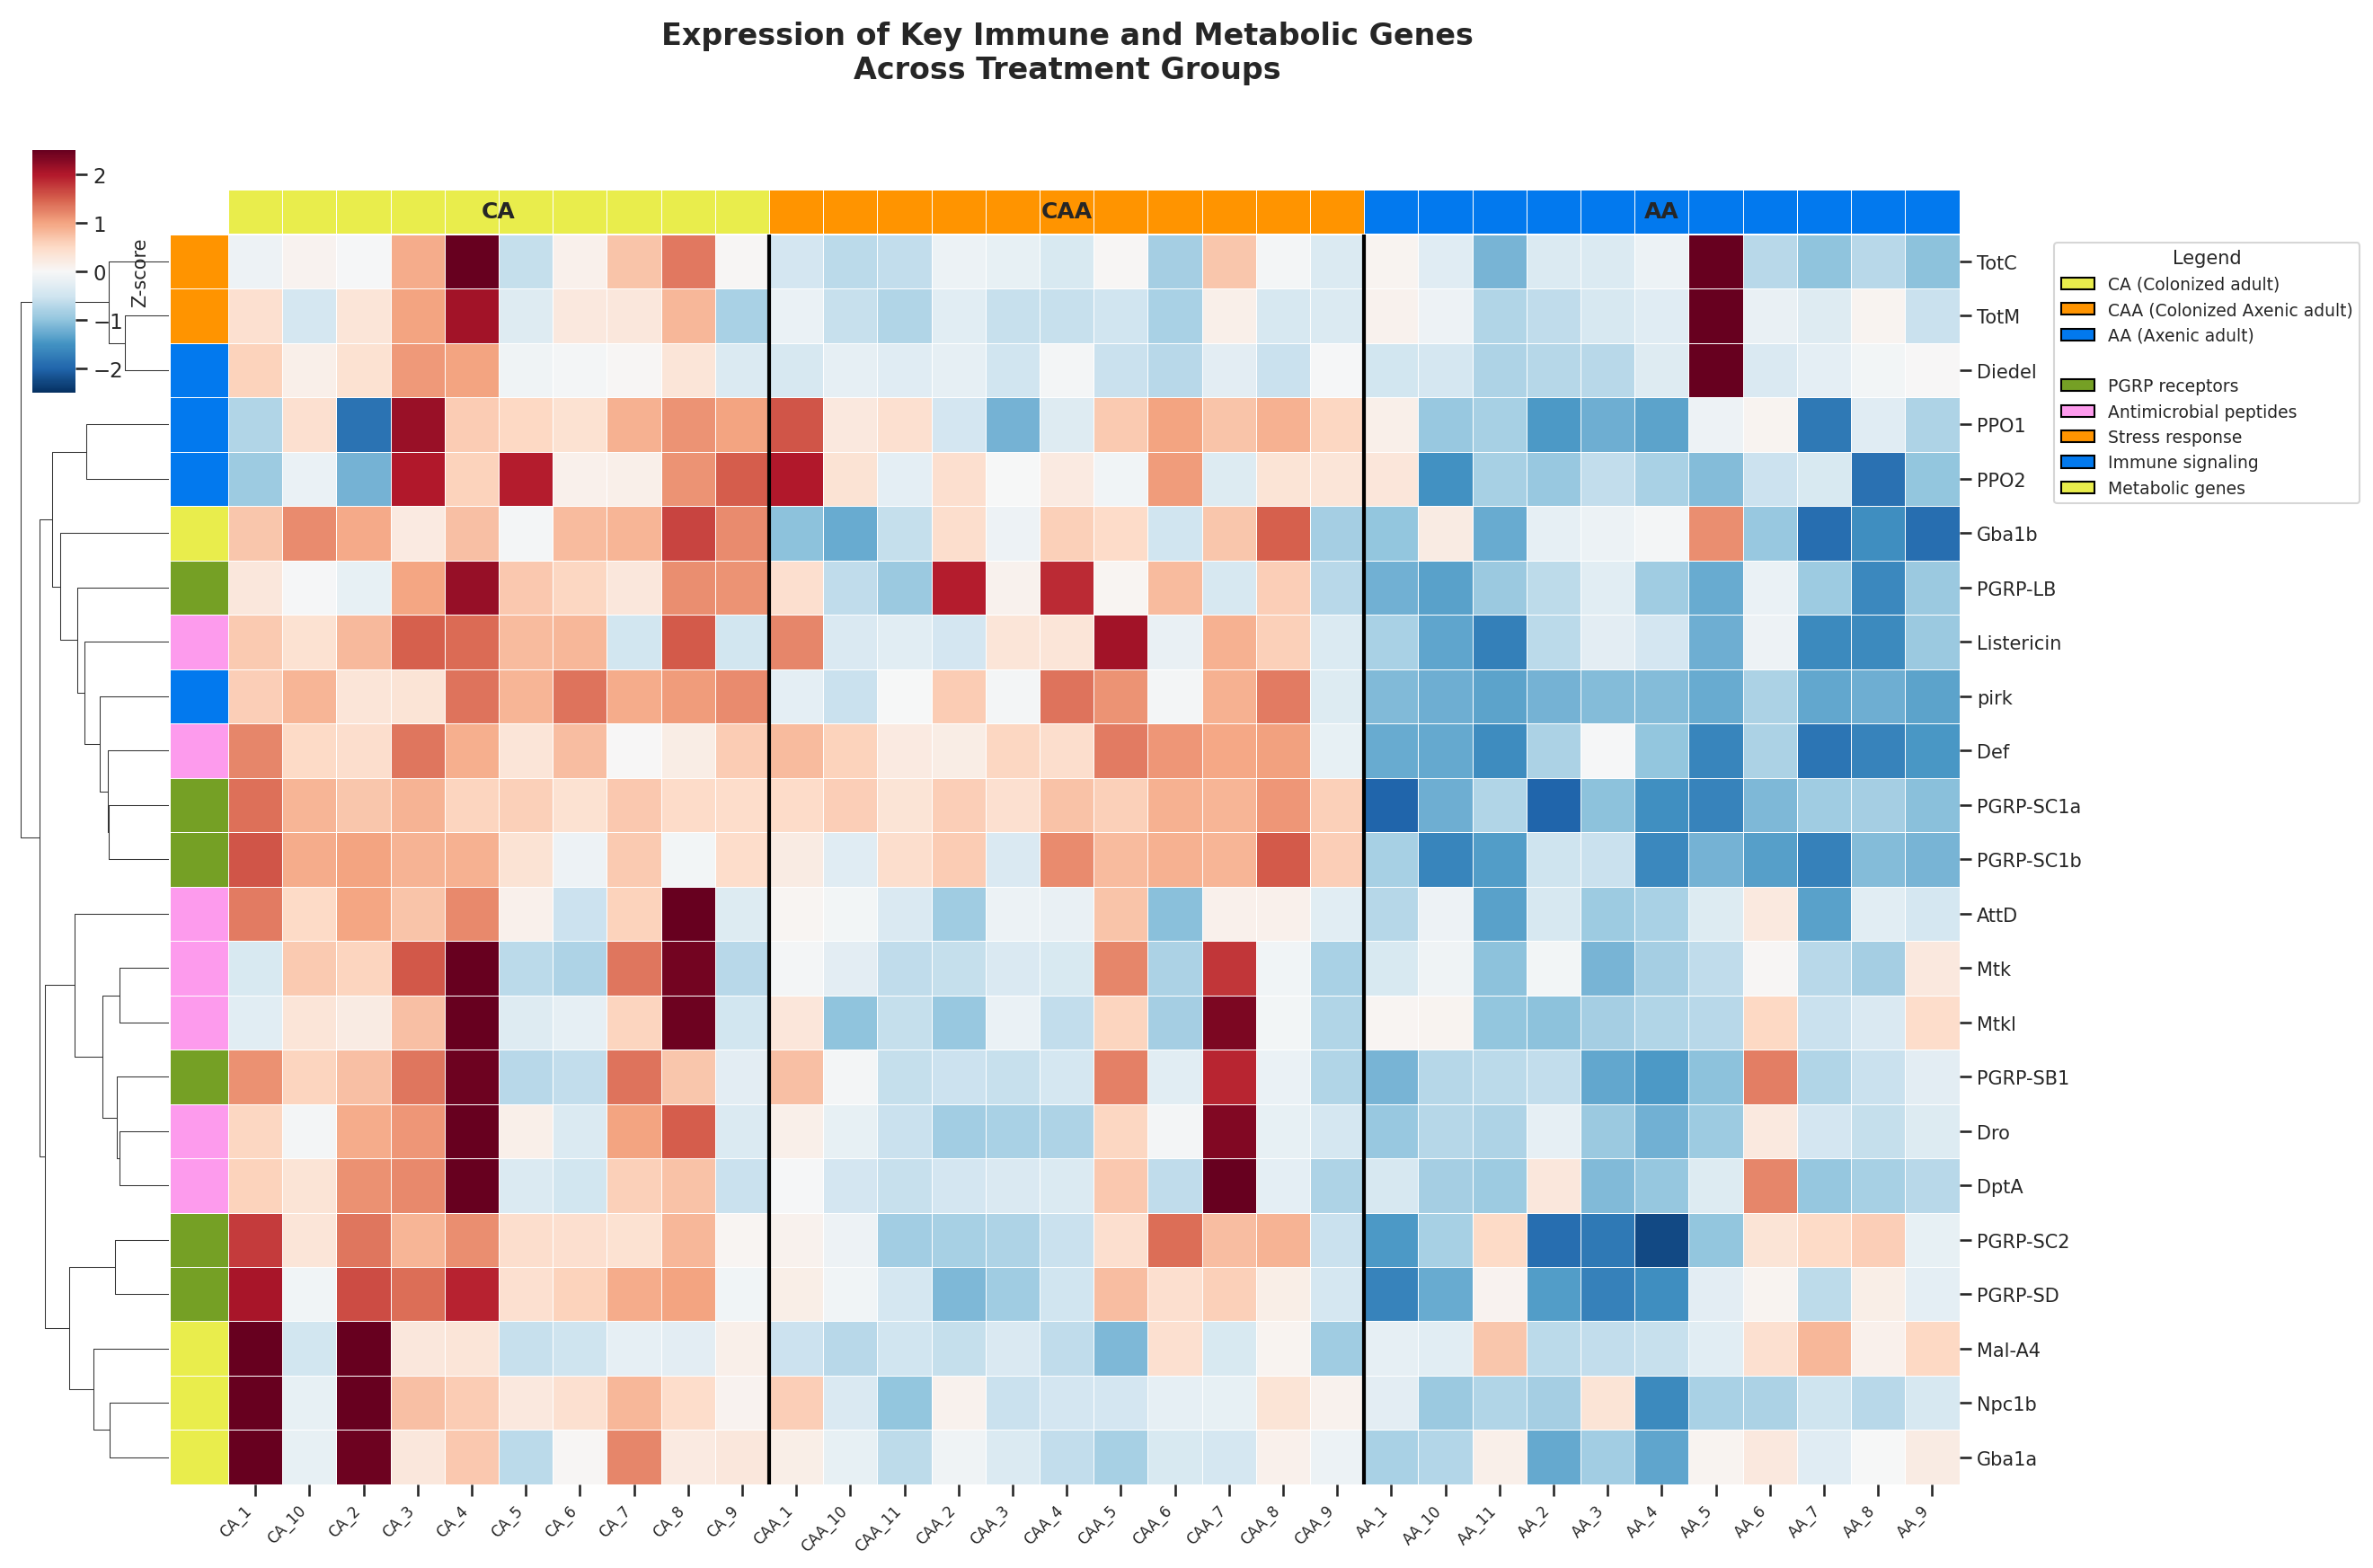

In [ ]:
"""
Heatmap of Key Immune and Metabolic Genes
=========================================
Heatmap showing expression of key immune and metabolic 
genes across all adult samples, organized by treatment group.
Every Sample is shown.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Liberation Sans', 'DejaVu Sans']
matplotlib.rcParams['svg.fonttype'] = 'none'
import seaborn as sns
from matplotlib.patches import Patch

# =============================================================================
# LOAD DATA
# =============================================================================
vst = pd.read_csv('vst_counts.csv')
vst = vst.set_index('gene_name')
if 'gene_id' in vst.columns:
    vst = vst.drop('gene_id', axis=1)

# =============================================================================
# DEFINE GENES TO SHOW
# =============================================================================
immune_genes = [
    # PGRPs
    'PGRP-LB', 'PGRP-SC1a', 'PGRP-SC1b', 'PGRP-SC2', 'PGRP-SD', 'PGRP-SB1',
    # AMPs
    'Def', 'Dro', 'Mtk', 'DptA', 'AttD', 'Listericin', 'Mtkl',
    # Stress response
    'TotM', 'TotC',
    # Other key genes
    'pirk', 'Diedel', 'PPO1', 'PPO2',
    # Metabolic genes
    'Mal-A4', 'Npc1b', 'Gba1a', 'Gba1b'
]

# Filter to available genes
available_genes = [g for g in immune_genes if g in vst.index]
vst_immune = vst.loc[available_genes]

# =============================================================================
# ORGANIZE SAMPLES BY GROUP
# =============================================================================
ca_samples = sorted([c for c in vst_immune.columns if c.startswith('A_inoA')])
caa_samples = sorted([c for c in vst_immune.columns if c.startswith('B1_reintro')])
aa_samples = sorted([c for c in vst_immune.columns if c.startswith('B2_conA')])

ordered_cols = ca_samples + caa_samples + aa_samples
vst_immune = vst_immune[ordered_cols]

# =============================================================================
# Z-SCORE NORMALIZE
# =============================================================================
vst_zscore = (vst_immune.T - vst_immune.mean(axis=1)).T
vst_zscore = (vst_zscore.T / vst_immune.std(axis=1)).T

# =============================================================================
# CREATE DISPLAY LABELS
# =============================================================================
col_labels = []
for col in vst_zscore.columns:
    if col.startswith('A_inoA'):
        col_labels.append(col.replace('A_inoA_', 'CA_'))
    elif col.startswith('B1_reintro'):
        col_labels.append(col.replace('B1_reintro_', 'CAA_'))
    else:
        col_labels.append(col.replace('B2_conA_', 'AA_'))

vst_display = vst_zscore.copy()
vst_display.columns = col_labels

# =============================================================================
# DEFINE COLORS - Modify these to match your preferences
# =============================================================================
# Column colors (treatment groups)
col_colors = []
for col in vst_display.columns:
    if col.startswith('CA_'):
        col_colors.append('#E9ED4C')  # Yellow for CA
    elif col.startswith('CAA_'):
        col_colors.append('#FF9400')  # Orange for CAA
    else:
        col_colors.append('#0279EE')  # Blue for AA

# Row colors (gene categories)
gene_categories = {
    'PGRP': ['PGRP-LB', 'PGRP-SC1a', 'PGRP-SC1b', 'PGRP-SC2', 'PGRP-SD', 'PGRP-SB1'],
    'AMP': ['Def', 'Dro', 'Mtk', 'DptA', 'AttD', 'Listericin', 'Mtkl'],
    'Stress': ['TotM', 'TotC'],
    'Immune': ['pirk', 'Diedel', 'PPO1', 'PPO2'],
    'Metabolic': ['Mal-A4', 'Npc1b', 'Gba1a', 'Gba1b']
}

category_colors = {
    'PGRP': '#75A025',
    'AMP': '#FD9BED',
    'Stress': '#FF9400',
    'Immune': '#0279EE',
    'Metabolic': '#E9ED4C'
}

row_colors = []
for gene in vst_display.index:
    for cat, genes in gene_categories.items():
        if gene in genes:
            row_colors.append(category_colors[cat])
            break
    else:
        row_colors.append('#ECE9E2')

# =============================================================================
# CREATE HEATMAP
# =============================================================================
g = sns.clustermap(vst_display, 
                   cmap='RdBu_r',
                   center=0,
                   vmin=-2.5, vmax=2.5,
                   col_cluster=False,
                   row_cluster=True,
                   col_colors=[col_colors],
                   row_colors=[row_colors],
                   figsize=(16, 12),
                   dendrogram_ratio=(0.08, 0.12),
                   cbar_pos=(0.02, 0.75, 0.02, 0.15),
                   linewidths=0.3,
                   linecolor='white',
                   xticklabels=True,
                   yticklabels=True)

# Style adjustments
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=10)
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.set_xlabel('')

# Title
g.fig.suptitle('Expression of Key Immune and Metabolic Genes\nAcross Treatment Groups', 
               fontsize=16, fontweight='bold', y=0.98)

# Group separator lines
n_ca = len(ca_samples)
n_caa = len(caa_samples)
g.ax_heatmap.axvline(x=n_ca, color='black', linewidth=2)
g.ax_heatmap.axvline(x=n_ca + n_caa, color='black', linewidth=2)

# Group labels
g.ax_col_colors.text(n_ca/2, 0.5, 'CA', ha='center', va='center', fontsize=12, fontweight='bold')
g.ax_col_colors.text(n_ca + n_caa/2, 0.5, 'CAA', ha='center', va='center', fontsize=12, fontweight='bold')
g.ax_col_colors.text(n_ca + n_caa + len(aa_samples)/2, 0.5, 'AA', ha='center', va='center', fontsize=12, fontweight='bold')

# Legend
legend_elements = [
    Patch(facecolor='#E9ED4C', edgecolor='black', label='CA (Colonized adult)'),
    Patch(facecolor='#FF9400', edgecolor='black', label='CAA (Colonized Axenic adult)'),
    Patch(facecolor='#0279EE', edgecolor='black', label='AA (Axenic adult)'),
    Patch(facecolor='white', edgecolor='white', label=''),
    Patch(facecolor='#75A025', edgecolor='black', label='PGRP receptors'),
    Patch(facecolor='#FD9BED', edgecolor='black', label='Antimicrobial peptides'),
    Patch(facecolor='#FF9400', edgecolor='black', label='Stress response'),
    Patch(facecolor='#0279EE', edgecolor='black', label='Immune signaling'),
    Patch(facecolor='#E9ED4C', edgecolor='black', label='Metabolic genes')
]

g.ax_heatmap.legend(handles=legend_elements, 
                    loc='upper left', bbox_to_anchor=(1.05, 1.0), # change where is the label, first on is left right, increase number right
                    title='Legend', fontsize=9, title_fontsize=10,
                    frameon=True, fancybox=True)

g.ax_cbar.set_ylabel('Z-score', fontsize=10)

# plt.savefig('Heatmap_Immune_Genes.png', dpi=300, bbox_inches='tight')
plt.show()
